Importing modules

In [56]:
import numpy as np
from ambiance import Atmosphere
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


Constants

In [57]:
mu_earth = 3.986004418e14                           # m^3/s^2
r_earth = 6.371e6                                   # m
h_target_orbit = 185e3                              # m

In [58]:
h_dawn = 120e3                                      # m
r_dawn = r_earth + h_dawn                           # m
v_dawn = 2000                                       # m/s

Specific energy of orbit calculator

In [59]:
def epsilon(r, v):
    return ((v**2/2) - (mu_earth/r))

Ground orbit values

In [60]:
epsilon_ground = epsilon(r_earth, 0)                        # m^2/s^2

Target orbit values

In [61]:
r_target_orbit = r_earth + h_target_orbit                   # m
v_target_orbit = np.sqrt(mu_earth / r_target_orbit)         # m/s
epsilon_target = epsilon(r_target_orbit, v_target_orbit)    # m^2/s^2

Energy calculations

In [62]:
dv_ground_target = np.sqrt(2 * abs(epsilon_target - epsilon_ground))


heights_m = [0, 7500,15000, 22500]
machs = [0, 1, 2, 3]

gains = np.zeros((len(heights_m), len(machs)))
speed_of_sound = np.zeros(len(heights_m))

for i, h in enumerate(heights_m):
    speed_of_sound[i] = Atmosphere(h).speed_of_sound[0] if h > 0 else 340.29399370096
    r_0 = r_earth + h
    epsilon_alt = epsilon(r_0, 0)
    dv_alt = np.sqrt(2 * abs(epsilon_target - epsilon_alt))
    dv_pot = dv_ground_target - dv_alt
    for j, mach in enumerate(machs):
        v_0 = mach * speed_of_sound[i]
        gains[i, j] = v_0 + dv_pot

df = pd.DataFrame(gains,
                  index   = [f"h = {h} km" for h in heights_m],
                  columns = [f"Mach {m}"   for m in machs])
print(df)


                 Mach 0      Mach 1      Mach 2       Mach 3
h = 0 km       0.000000  340.293994  680.587987  1020.881981
h = 7500 km    9.177273  319.389663  629.602054   939.814445
h = 15000 km  18.343477  313.412970  608.482464   903.551957
h = 22500 km  27.498650  324.211978  620.925305   917.638633


Dawn Case

In [63]:
epsilon_dawn = epsilon(r_dawn, 0)
dv_dawn_target = np.sqrt(2 * abs(epsilon_target - epsilon_dawn))
dv_pot_dawn = dv_ground_target - dv_dawn_target
gain_dawn = dv_pot_dawn + v_dawn

print(f"Dawn gain: {gain_dawn} m/s")

Dawn gain: 2145.529157525203 m/s


Plots

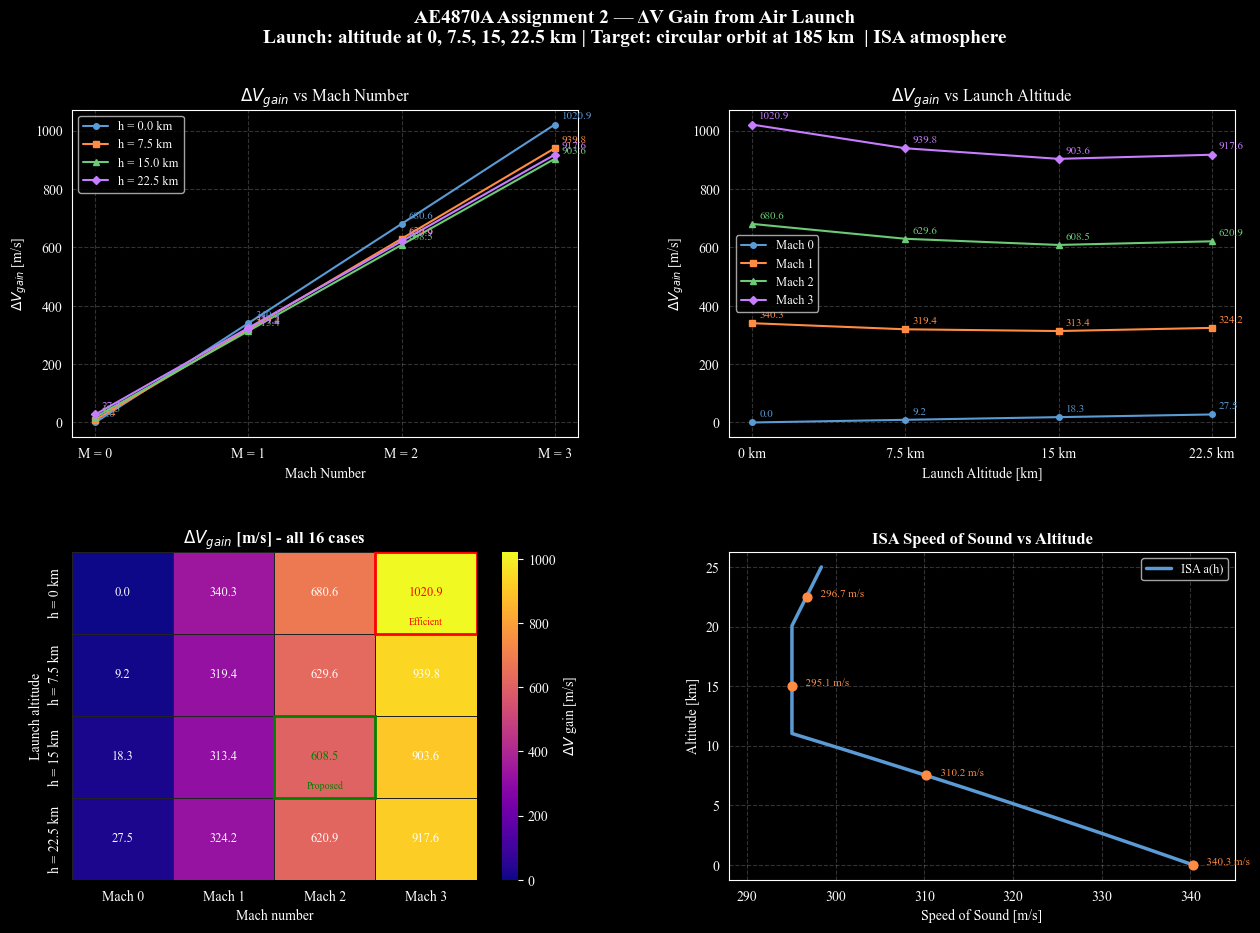

In [72]:
plt.style.use("dark_background")
plt.rcParams["font.family"] = "Times New Roman"

colors  = ["#5B9BD5", "#FF8C42", "#6BCB77", "#C77DFF"]
markers = ["o", "s", "^", "D"]

fig, axes = plt.subplots(2, 2, figsize = (15, 10))
fig.suptitle("AE4870A Assignment 2 — ΔV Gain from Air Launch\n" "Launch: altitude at 0, 7.5, 15, 22.5 km | Target: circular orbit at 185 km  | ISA atmosphere", fontsize = 14, fontweight = 'bold')

ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

for i, h_m in enumerate(heights_m):
    h_km = h_m / 1e3
    ax1.plot(machs, gains[i,:], color = colors[i], marker = markers[i], markersize = 4, linestyle = "-", linewidth = 1.5, label = f"h = {h_km} km")
    [ax1.annotate(f"{gains[i,j]:.1f}", xy=(machs[j], gains[i,j]), xytext=(5,4), textcoords="offset points", fontsize=8, color=colors[i]) for j in range(len(machs))]


h_km = [0, 7.5, 15, 22.5]
for j, mach in enumerate(machs):
    ax2.plot(h_km, gains[:, j], color = colors[j], marker = markers[j], markersize = 4, linestyle = "-", linewidth = 1.5, label = f"Mach {mach}" )
    [ax2.annotate(f"{gains[i,j]:.1f}", xy=(h_km[i], gains[i,j]), xytext=(5,4), textcoords="offset points", fontsize=8, color=colors[j]) for i in range(len(h_km))]

row_labels = [f"h = {h} km" for h in h_km]
col_labels = [f"Mach {m}"   for m in machs]
sns.heatmap(gains, annot = True,  annot_kws={"size": 9, "color": "white"},  fmt = ".1f", xticklabels = col_labels, yticklabels = row_labels, cmap="plasma", linewidths=0.5, linecolor="#222222",cbar_kws={"label": r"$\Delta V$ gain [m/s]"}, ax = ax3)
max_dv = np.unravel_index(np.argmax(gains), gains.shape)
ax3.add_patch(plt.Rectangle((max_dv[1], max_dv[0]), 1, 1, fill = False, edgecolor = "red", linewidth = 2.0))
ax3.add_patch(plt.Rectangle((2, 2), 1, 1, fill=False, edgecolor="green", linewidth=2.0))
ax3.texts[max_dv[0] * gains.shape[1] + max_dv[1]].set_color("red")
ax3.texts[2 * gains.shape[1] + 2].set_color("green")

ax3.text(2.5, 2.85, "Proposed", ha="center", va="center", fontsize=7, color="green", fontfamily="Times New Roman")
ax3.text(3.5, 0.85, "Efficient", ha="center", va="center", fontsize=7, color="red", fontfamily="Times New Roman")

h_fine = np.linspace(1, 25000, 500)
a_fine = np.array([Atmosphere(h).speed_of_sound[0] for h in h_fine])
ax4.plot(a_fine, h_fine / 1000, color="#5B9BD5", linewidth=2.5, label="ISA a(h)")

for i in range(len(h_km)):
    ax4.scatter(speed_of_sound[i], h_km[i], color="#FF8C42", zorder=4, s=40)
    ax4.annotate(f"  {speed_of_sound[i]:.1f} m/s", xy=(speed_of_sound[i], h_km[i]), xytext=(6, 0), textcoords="offset points", fontsize=8, color="#FF8C42")

ax1. set_title(r"$\Delta V_{gain}$ vs Mach Number")
ax1.set_xlabel("Mach Number")
ax1.set_ylabel(r"$\Delta V_{gain}$ [m/s]")
ax1.set_xticks(machs)
ax1.set_xticklabels([f"M = {m}" for m in machs])
ax1.legend(fontsize = 9)
ax1.grid(True, linestyle="--", alpha=0.2)

ax2. set_title(r"$\Delta V_{gain}$ vs Launch Altitude")
ax2.set_xlabel("Launch Altitude [km]")
ax2.set_ylabel(r"$\Delta V_{gain}$ [m/s]")
ax2.set_xticks(h_km)
ax2.set_xticklabels([f"{h} km" for h in h_km])
# ax2.set_ylim(-5, 100)
ax2.legend(fontsize = 9)
ax2.grid(True, linestyle="--", alpha=0.2)

ax3.set_title(r"$\Delta V_{gain}$ [m/s] - all 16 cases", fontweight="bold")
ax3.set_xlabel("Mach number")
ax3.set_ylabel("Launch altitude")

ax4.set_title("ISA Speed of Sound vs Altitude", fontweight="bold")
ax4.set_xlabel("Speed of Sound [m/s]")
ax4.set_ylabel("Altitude [km]")
ax4.set_xlim(288, 345)
# ax4.set_ylim(-1, 26)
ax4.legend(fontsize=9)
ax4.grid(True, linestyle="--", alpha=0.2)

plt.subplots_adjust(hspace=0.35, wspace=0.3)

plt.savefig("assignment2_partb.png", dpi=150, bbox_inches="tight")
plt.show()